# Climate Risk & Mortgage Default Model
**Research Question:** Does fire exposure (realized) and fire weather risk (latent) predict mortgage defaults beyond traditional credit variables?

**Approach:**
- Baseline model: credit variables only → default probability (PR-AUC benchmark)
- Climate model: credit variables + MTBS fire exposure + Open-Meteo fire weather → default probability
- Delta between models = quantified climate risk contribution

**Key finding from EDA:**
- 6,511 defaults (26% of total) came from disaster-flagged loans that never hit numeric delinquency threshold
- Traditional credit models would have rated these as performing
- Baseline PR-AUC: 0.2442 (5.38x lift over random)

## 1. Imports & Setup

In [1]:
%pip install openmeteo-requests requests-cache retry-requests
%pip install geopandas xgboost shap scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import openmeteo_requests
import requests_cache
from retry_requests import retry
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import shap
import time

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_columns', 50)

## 2. Wildfire Data (MTBS)

In [3]:
# Load MTBS fire perimeter data
mtbs_perim_df = gpd.read_file('./mtbs_perimeter_data/mtbs_perims_DD.shp', encoding='utf-8')
mtbs_fod_df   = gpd.read_file('./mtbs_fod_pts_data/mtbs_FODpoints_DD.shp')

print('MTBS perimeters shape:', mtbs_perim_df.shape)
print('Columns:', mtbs_perim_df.columns.tolist())

MTBS perimeters shape: (30730, 23)
Columns: ['Event_ID', 'irwinID', 'Incid_Name', 'Incid_Type', 'Map_ID', 'Map_Prog', 'Asmnt_Type', 'BurnBndAc', 'BurnBndLat', 'BurnBndLon', 'Ig_Date', 'Pre_ID', 'Post_ID', 'Perim_ID', 'dNBR_offst', 'dNBR_stdDv', 'NoData_T', 'IncGreen_T', 'Low_T', 'Mod_T', 'High_T', 'Comment', 'geometry']


In [4]:
# Build severity score from pixel counts
# Low=1, Moderate=2, High=3 — weighted average normalized to 0-1
mtbs_perim_df['total_pixels'] = (
    mtbs_perim_df['Low_T'] +
    mtbs_perim_df['Mod_T'] +
    mtbs_perim_df['High_T']
)

mtbs_perim_df['severity_score'] = (
    (mtbs_perim_df['Low_T']  * 1 +
     mtbs_perim_df['Mod_T']  * 2 +
     mtbs_perim_df['High_T'] * 3) /
    (mtbs_perim_df['total_pixels'] * 3)
)

# Extract fire year
mtbs_perim_df['fire_year'] = pd.to_datetime(mtbs_perim_df['Ig_Date']).dt.year

print(mtbs_perim_df[['Incid_Name', 'fire_year', 'BurnBndAc', 'severity_score']].head())
print('\nYear range:', mtbs_perim_df['fire_year'].min(), '-', mtbs_perim_df['fire_year'].max())

  Incid_Name  fire_year  BurnBndAc  severity_score
0  CAMELBACK       1985       4780          0.8112
1  SUGARLOAF       1985       5489          0.8451
2  TAL NW 44       1985       1491          0.8538
3  GAL NE 48       1985       1298          0.8265
4    UNNAMED       1985       1326          0.8645

Year range: 1984 - 2024


In [5]:
# Filter to 2011+ (fires that could affect 2014-2024 mortgages via lag)
mtbs_filtered = mtbs_perim_df[mtbs_perim_df['fire_year'] >= 2011].copy()
print('Fires 2011+:', mtbs_filtered.shape[0])
print(mtbs_filtered['fire_year'].value_counts().sort_index())

Fires 2011+: 12300
fire_year
2011    1332
2012     835
2013     650
2014     693
2015     868
2016     975
2017     987
2018     986
2019     814
2020     815
2021    1021
2022    1177
2023     454
2024     693
Name: count, dtype: int64


In [6]:
# Load ZCTA shapefile (Census 2023)
# If not already downloaded: gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2023/ZCTA520/tl_2023_us_zcta520.zip')
zctas = gpd.read_file('us_zctas.geojson')
print('ZCTAs shape:', zctas.shape)
print('Columns:', zctas.columns.tolist())

ZCTAs shape: (33791, 11)
Columns: ['zip', 'GEOID20', 'GEOIDFQ20', 'CLASSFP20', 'MTFCC20', 'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20', 'geometry']


In [7]:
# Spatial join: ZCTA x MTBS fire perimeters
# Using Albers Equal Area (EPSG:5070) for accurate area calculations
zctas_proj = zctas.to_crs('EPSG:5070')
mtbs_proj  = mtbs_filtered.to_crs('EPSG:5070')

# Include Ig_Date in the spatial join
zip_hits = gpd.sjoin(
    zctas_proj,
    mtbs_proj[['Event_ID', 'fire_year', 'Ig_Date', 'BurnBndAc', 'severity_score', 'geometry']],
    how='inner',
    predicate='intersects'
)

zip_hits['fire_month'] = pd.to_datetime(zip_hits['Ig_Date']).dt.month

# Calculate what % of each ZCTA was actually burned
zip_hits['intersection_area'] = zip_hits.apply(
    lambda row: zctas_proj.loc[row.name, 'geometry'].intersection(
        mtbs_proj.loc[row['index_right'], 'geometry']
    ).area,
    axis=1
)

zip_hits['zcta_area']  = zctas_proj.loc[zip_hits.index, 'geometry'].area.values
zip_hits['pct_burned'] = zip_hits['intersection_area'] / zip_hits['zcta_area']

print('zip_hits shape:', zip_hits.shape)
print(zip_hits[['zip', 'fire_year', 'pct_burned', 'severity_score']].head())

zip_hits shape: (17368, 21)
      zip  fire_year  pct_burned  severity_score
45  46368       2021      0.0334          0.8304
99  40769       2021      0.0000          0.8312
99  40769       2019      0.0058          0.9840
99  40769       2016      0.0074          0.8323
99  40769       2021      0.0000          0.8320


In [8]:
zip_year_month_exposure = zip_hits.groupby(['zip', 'fire_year', 'fire_month']).agg(
    total_pct_burned=('pct_burned', 'sum'),
    max_pct_burned  =('pct_burned', 'max'),
    fire_count      =('pct_burned', 'count'),
    avg_severity    =('severity_score', 'mean'),
    max_severity    =('severity_score', 'max'),
    total_acres     =('BurnBndAc', 'sum')
).reset_index()

zip_year_month_exposure['zip3'] = (
    zip_year_month_exposure['zip']
    .astype(str).str.zfill(5).str[:3]
)

zip3_year_month_exposure = zip_year_month_exposure.groupby(
    ['zip3', 'fire_year', 'fire_month']
).agg(
    total_pct_burned=('total_pct_burned', 'sum'),
    max_pct_burned  =('max_pct_burned',   'max'),
    fire_count      =('fire_count',       'sum'),
    avg_severity    =('avg_severity',     'mean'),
    max_severity    =('max_severity',     'max'),
    total_acres     =('total_acres',      'sum')
).reset_index()

# Add fire_period (YYYYMM integer for month arithmetic)
zip3_year_month_exposure['fire_period'] = (
    zip3_year_month_exposure['fire_year'] * 100 + 
    zip3_year_month_exposure['fire_month']
)

print(zip3_year_month_exposure.shape)
print(zip3_year_month_exposure.head(10))

(6068, 10)
  zip3  fire_year  fire_month  total_pct_burned  max_pct_burned  fire_count  \
0  007       2013           3            0.0156          0.0156           1   
1  012       2021           5            0.0316          0.0282           2   
2  074       2024          11            0.1403          0.1400           2   
3  080       2012           4            0.0068          0.0068           1   
4  080       2014           5            0.0517          0.0516           2   
5  080       2015           5            0.0068          0.0068           1   
6  080       2015           9            0.0012          0.0012           1   
7  080       2017           7            0.0002          0.0002           1   
8  080       2018           4            0.0113          0.0113           1   
9  080       2019           3            0.1005          0.0989           2   

   avg_severity  max_severity  total_acres  fire_period  
0        0.8298        0.8298          631       201303  
1  

## 3. Weather Data (Open-Meteo)
Pull fire weather variables per zip3 centroid to build **forward-looking climate risk** features.



In [9]:
# Get zip3 centroids from ZCTA file
zcta_centroids = zctas.copy().to_crs('EPSG:4326')
zcta_centroids['zip3'] = zcta_centroids['zip'].astype(str).str.zfill(5).str[:3]
zcta_centroids['lat']  = zcta_centroids.geometry.centroid.y
zcta_centroids['lon']  = zcta_centroids.geometry.centroid.x

zip3_centroids = (
    zcta_centroids.groupby('zip3')[['lat', 'lon']]
    .mean()
    .reset_index()
)

print(f'Unique zip3 centroids: {len(zip3_centroids)}')

/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/4228928169.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zcta_centroids['lat']  = zcta_centroids.geometry.centroid.y
/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/4228928169.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zcta_centroids['lon']  = zcta_centroids.geometry.centroid.x


Unique zip3 centroids: 896


In [10]:
# 1. Load FEMA NRI census tract data
nri = pd.read_csv('./NRI_Table_CensusTracts/NRI_Table_CensusTracts.csv')

# Wildfire specific columns
whp_cols = [c for c in nri.columns if 'WLDF' in c]
print(whp_cols)
# WLDF_RISKS = wildfire risk score
# WLDF_EVNTS = annualized frequency
# WLDF_EXPB  = exposure buildings

# 2. Load HUD tract-to-zip crosswalk
# Download from: huduser.gov/portal/datasets/usps_crosswalk.html
crosswalk = pd.read_excel('ZIP_TRACT_122025.xlsx')

# 3. Join NRI to crosswalk
nri_zip = nri.merge(crosswalk, left_on='TRACTFIPS', right_on='TRACT', how='left')

# 4. Aggregate to zip3
nri_zip['zip3'] = nri_zip['ZIP'].astype(str).str.zfill(5).str[:3]

[]


In [11]:
wfir_cols = [
    'WFIR_RISKS',   # wildfire risk score (composite)
    'WFIR_RISKR',   # risk rating (Very High/High/etc)
    'WFIR_EVNTS',   # annualized frequency of wildfire events
    'WFIR_AFREQ',   # annualized frequency normalized
    'WFIR_EXPB',    # building exposure
    'WFIR_EALB',    # expected annual loss - buildings
    'WFIR_EALT',    # expected annual loss - total
]

# Convert to numeric first
for col in wfir_cols:
    nri_zip[col] = pd.to_numeric(nri_zip[col], errors='coerce')

# Now aggregate
zip3_whp = nri_zip.groupby('zip3')[wfir_cols].mean().reset_index()

zip3_whp = zip3_whp.rename(columns={
    'WFIR_RISKS': 'wfir_risk_score',
    'WFIR_EVNTS': 'wfir_events',
    'WFIR_AFREQ': 'wfir_freq',
    'WFIR_EXPB':  'wfir_building_exposure',
    'WFIR_EALB':  'wfir_annual_loss_buildings',
    'WFIR_EALT':  'wfir_annual_loss_total',
})

print(zip3_whp.shape)
print(zip3_whp['wfir_risk_score'].describe())

(863, 8)
count   850.0000
mean     59.5243
std      21.6909
min       0.0000
25%      44.7197
50%      61.1953
75%      76.8028
max      99.3969
Name: wfir_risk_score, dtype: float64


## 4. Mortgage Data

In [12]:
# Load Fannie Mae loan performance data
mortgage = pd.read_csv('final_master_loan_data.csv')
print('Shape:', mortgage.shape)
print('Columns:', mortgage.columns.tolist())

/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/1088675303.py:2: DtypeWarning: Columns (3,7,23,24,28,29,57,58,59,62) have mixed types. Specify dtype option on import or set low_memory=False.
  mortgage = pd.read_csv('final_master_loan_data.csv')


Shape: (23248344, 63)
Columns: ['Loan_ID', 'Monthly Reporting Period', 'Current Actual UPB', 'Current Loan Delinquency Status', 'Loan Age', 'Remaining Months to Legal Maturity', 'Defect Settlement Date', 'Modification Flag', 'Zero Balance Code', 'Zero Balance Effective Date', 'Current Interest Rate', 'Current Deferred UPB', 'Due Date of Last Paid Installment (DDLPI)', 'MI Recoveries', 'Net Sales Proceeds', 'Non MI Recoveries', 'Expenses', 'Legal Costs', 'Maintenance and Preservation Costs', 'Taxes and Insurance', 'Miscellaneous Expenses', 'Actual Loss Calculation', 'Modification Cost', 'Step Modification Flag', 'Deferred Payment Plan', 'Estimated Loan-to-Value (ELTV)', 'Zero Balance Removal UPB', 'Delinquent Accrued Interest', 'Delinquency Due to Disaster', 'Borrower Assistance Status Code', 'Current Month Modification Cost', 'Interest Bearing UPB', 'Credit Score', 'First Payment Date', 'First Time Homebuyer Flag', 'Maturity Date', 'Metropolitan Statistical Area (MSA) Or Metropolitan D

In [69]:
# ── Clean delinquency column ──────────────────────────────────────────────────
mortgage['Current Loan Delinquency Status'] = (
    mortgage['Current Loan Delinquency Status']
    .astype(str).str.strip()
)

mortgage['Delinquency_Numeric'] = pd.to_numeric(
    mortgage['Current Loan Delinquency Status'],
    errors='coerce'  # 'RA' and other codes → NaN
)

# Fill null disaster flag (null = not a disaster, not missing)
mortgage['Delinquency Due to Disaster'] = (
    mortgage['Delinquency Due to Disaster'].fillna('N')
)

# ── Construct default flag ────────────────────────────────────────────────────
# Three components:
# 1. 90+ days delinquent (numeric >= 3)
# 2. Repayment agreement (RA) — loss mitigation
mortgage['Default'] = (
    (mortgage['Delinquency_Numeric'] >= 3) |
    (mortgage['Current Loan Delinquency Status'] == 'RA')
).astype(int)

loan_level_check = mortgage.groupby('Loan_ID')['Default'].max()
print(f'Unique loans:   {mortgage["Loan_ID"].nunique():,}')
print(f'Total defaults: {loan_level_check.sum():,}')
print(f'Default rate:   {loan_level_check.mean():.4f}')

Unique loans:   550,000
Total defaults: 18,455
Default rate:   0.0336


In [70]:
# ── Clean sentinel values ─────────────────────────────────────────────────────
mortgage['Credit Score']                          = mortgage['Credit Score'].replace(9999, np.nan)
mortgage['Original Loan-to-Value (LTV)']          = mortgage['Original Loan-to-Value (LTV)'].replace(999, np.nan)
mortgage['Original Combined Loan-to-Value (CLTV)']= mortgage['Original Combined Loan-to-Value (CLTV)'].replace(999, np.nan)
mortgage['Original Debt-to-Income (DTI) Ratio']   = mortgage['Original Debt-to-Income (DTI) Ratio'].replace(999, np.nan)
mortgage['Estimated Loan-to-Value (ELTV)']        = mortgage['Estimated Loan-to-Value (ELTV)'].replace(999, np.nan)

# Remove clearly erroneous LTV/ELTV outliers (only 21 and 1,152 rows respectively)
mortgage.loc[mortgage['Original Loan-to-Value (LTV)']           > 200, 'Original Loan-to-Value (LTV)']           = np.nan
mortgage.loc[mortgage['Original Combined Loan-to-Value (CLTV)'] > 200, 'Original Combined Loan-to-Value (CLTV)'] = np.nan
mortgage.loc[mortgage['Estimated Loan-to-Value (ELTV)']         > 200, 'Estimated Loan-to-Value (ELTV)']         = np.nan

print('Cleaned. Remaining nulls:')
print(mortgage[['Credit Score',
                'Original Loan-to-Value (LTV)',
                'Original Combined Loan-to-Value (CLTV)',
                'Original Debt-to-Income (DTI) Ratio',
                'Estimated Loan-to-Value (ELTV)']].isnull().sum())

Cleaned. Remaining nulls:
Credit Score                                 4031
Original Loan-to-Value (LTV)                 2542
Original Combined Loan-to-Value (CLTV)       3723
Original Debt-to-Income (DTI) Ratio       1238956
Estimated Loan-to-Value (ELTV)            4429879
dtype: int64


In [71]:
# ── Drop columns not useful for modeling ─────────────────────────────────────
drop_cols = [
    'Defect Settlement Date', 'MI Recoveries', 'Net Sales Proceeds',
    'Non MI Recoveries', 'Expenses', 'Legal Costs',
    'Maintenance and Preservation Costs', 'Taxes and Insurance',
    'Miscellaneous Expenses', 'Actual Loss Calculation', 'Modification Cost',
    'Step Modification Flag', 'Deferred Payment Plan', 'Zero Balance Removal UPB',
    'Delinquent Accrued Interest', 'Pre-HARP Loan Sequence Number',
    'HARP Indicator', 'Borrower Assistance Status Code'
]
mortgage = mortgage.drop(columns=drop_cols, errors='ignore')

# ── Add year and zip3 ─────────────────────────────────────────────────────────
mortgage['year'] = pd.to_datetime(
    mortgage['Monthly Reporting Period'], format='%Y%m'
).dt.year

mortgage['zip3'] = (
    mortgage['Postal Code']
    .astype(float).astype(int).astype(str)
    .str.zfill(5).str[:3]
)

print('Final mortgage shape:', mortgage.shape)
print('Year range:', mortgage['year'].min(), '-', mortgage['year'].max())

Final mortgage shape: (23248344, 51)
Year range: 2014 - 2025


### 4.1 EDA

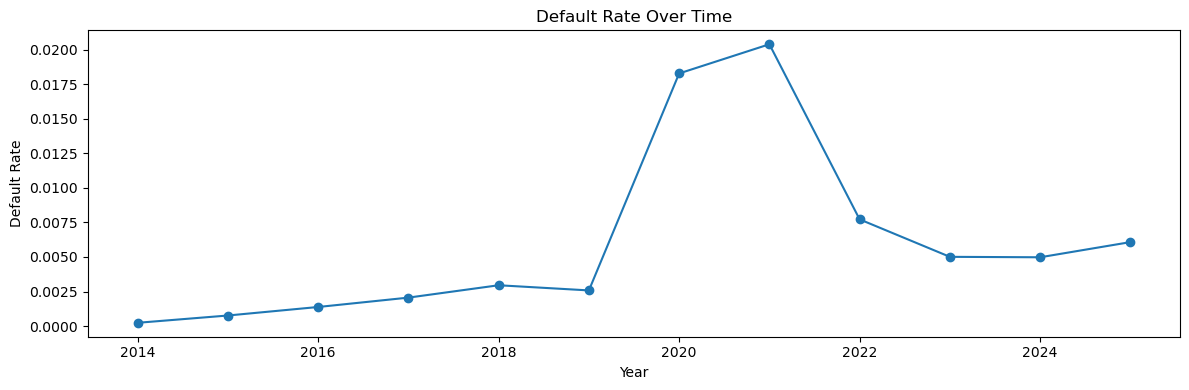

In [72]:
# Default rate over time
default_over_time = mortgage.groupby('year')['Default'].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(default_over_time['year'], default_over_time['Default'], marker='o')
plt.title('Default Rate Over Time')
plt.ylabel('Default Rate')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/3045085796.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cs_default = mortgage.groupby(
/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/3045085796.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ltv_default = mortgage.groupby(
/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/3045085796.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

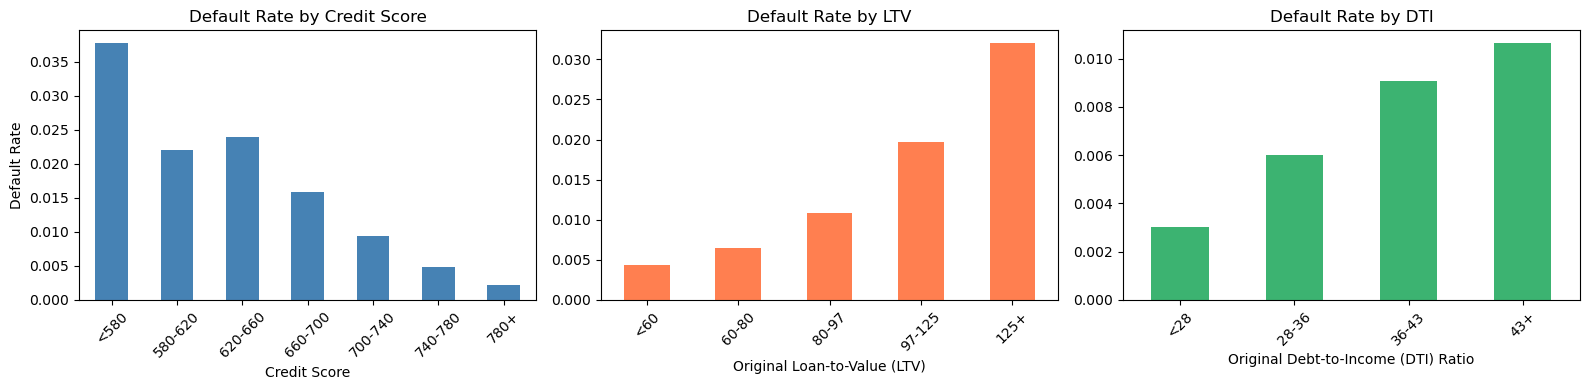

In [73]:
# Default rate by key credit segments
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Credit score
cs_default = mortgage.groupby(
    pd.cut(mortgage['Credit Score'],
           bins=[300, 580, 620, 660, 700, 740, 780, 850],
           labels=['<580','580-620','620-660','660-700','700-740','740-780','780+'])
)['Default'].mean()
cs_default.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Default Rate by Credit Score')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=45)

# LTV
ltv_default = mortgage.groupby(
    pd.cut(mortgage['Original Loan-to-Value (LTV)'],
           bins=[0, 60, 80, 97, 125, 200],
           labels=['<60','60-80','80-97','97-125','125+'])
)['Default'].mean()
ltv_default.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Default Rate by LTV')
axes[1].tick_params(axis='x', rotation=45)

# DTI
dti_default = mortgage.groupby(
    pd.cut(mortgage['Original Debt-to-Income (DTI) Ratio'],
           bins=[0, 28, 36, 43, 65],
           labels=['<28','28-36','36-43','43+'])
)['Default'].mean()
dti_default.plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Default Rate by DTI')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [74]:
# Define disaster loan ids
disaster_loan_ids = mortgage[mortgage['Delinquency Due to Disaster'] == 'Y']['Loan_ID'].unique()

disaster_default_rate = (
    mortgage[mortgage['Loan_ID'].isin(disaster_loan_ids)]
    .groupby('Loan_ID')['Default'].max().mean()
)
non_disaster_default_rate = (
    mortgage[~mortgage['Loan_ID'].isin(disaster_loan_ids)]
    .groupby('Loan_ID')['Default'].max().mean()
)

print(f'Disaster-flagged loans:     {len(disaster_loan_ids):,}')
print(f'Disaster default rate:      {disaster_default_rate:.4f}')
print(f'Non-disaster default rate:  {non_disaster_default_rate:.4f}')
print(f'Lift:                       {disaster_default_rate / non_disaster_default_rate:.2f}x')

# Aggregate to loan level
loan_flags = mortgage.groupby('Loan_ID').agg(
    ever_disaster  =('Delinquency Due to Disaster', lambda x: (x == 'Y').any()),
    ever_default   =('Default', 'max'),
    max_delinquency=('Delinquency_Numeric', 'max')
).reset_index()

# With clean default definition, disaster_only_defaults = 
# loans flagged as disaster AND defaulted via RA (not 90+ days)
disaster_only_defaults = (
    loan_flags['ever_disaster'] &
    (loan_flags['ever_default'] == 1) &
    (loan_flags['max_delinquency'] < 3)
).sum()

total_defaults = loan_flags['ever_default'].sum()

print(f'\nDisaster-flagged loans that defaulted via RA only: {disaster_only_defaults:,}')
print(f'As % of total defaults:                            {disaster_only_defaults/total_defaults*100:.1f}%')

# More useful — what % of defaults were disaster-flagged at any point
disaster_defaults = (
    loan_flags['ever_disaster'] &
    (loan_flags['ever_default'] == 1)
).sum()

print(f'\nDefaults that were ever disaster-flagged: {disaster_defaults:,}')
print(f'As % of total defaults:                   {disaster_defaults/total_defaults*100:.1f}%')

Disaster-flagged loans:     20,000
Disaster default rate:      0.6744
Non-disaster default rate:  0.0094
Lift:                       71.98x

Disaster-flagged loans that defaulted via RA only: 0
As % of total defaults:                            0.0%

Defaults that were ever disaster-flagged: 13,489
As % of total defaults:                   73.1%


In [75]:
# Merge back year and state for concentration analysis
loan_meta = mortgage.groupby('Loan_ID')[['year', 'Property State']].first().reset_index()
loan_flags = loan_flags.merge(loan_meta, on='Loan_ID')

print(loan_flags[loan_flags['ever_disaster']]['year'].value_counts().sort_index())
print(loan_flags[loan_flags['ever_disaster']]['Property State'].value_counts().head(10))

year
2014    1618
2015    2082
2016    2815
2017    3547
2018    3340
2019    3552
2020    1431
2021     557
2022     684
2023     282
2024      91
2025       1
Name: count, dtype: int64
Property State
CA    2919
FL    2462
TX    2082
NY    1066
IL     895
NJ     734
GA     663
MI     593
NC     509
PA     503
Name: count, dtype: int64


In [22]:
ca_disaster = loan_flags[
    (loan_flags['ever_disaster']) & 
    (loan_flags['Property State'] == 'CA')
]['Loan_ID'].unique()

ca_zip3s = mortgage[mortgage['Loan_ID'].isin(ca_disaster)]['zip3'].unique()
ca_fire_exposed = zip3_year_month_exposure[
    zip3_year_month_exposure['zip3'].isin(ca_zip3s)
]['zip3'].nunique()

print(f'CA disaster loan zip3s:        {len(ca_zip3s)}')
print(f'Of those, zip3s with fires:    {ca_fire_exposed}')
print(f'Coverage:                      {ca_fire_exposed/len(ca_zip3s)*100:.1f}%')

CA disaster loan zip3s:        56
Of those, zip3s with fires:    38
Coverage:                      67.9%


In [23]:
ca_loans = mortgage[mortgage['Property State'] == 'CA'].copy()
ca_loans['fire_exposed'] = ca_loans['zip3'].isin(
    zip3_year_month_exposure['zip3'].unique()
).astype(int)

ca_default = ca_loans.groupby(['fire_exposed', 'Loan_ID'])['Default'].max().reset_index()
print(ca_default.groupby('fire_exposed')['Default'].mean().round(4))

fire_exposed
0   0.0434
1   0.0393
Name: Default, dtype: float64


## 5. Merge: Mortgage + Fire Exposure + Weather

In [76]:
# Vectorized period shift — no apply needed
def add_months_to_period(period_series, n_months):
    year = period_series // 100
    month = period_series % 100
    # Convert to total months, add lag, convert back
    total_months = year * 12 + month - 1 + n_months
    new_year = total_months // 12
    new_month = total_months % 12 + 1
    return new_year * 100 + new_month

# Build mortgage period
mortgage['month'] = pd.to_datetime(
    mortgage['Monthly Reporting Period'], format='%Y%m'
).dt.month
mortgage['period'] = mortgage['year'] * 100 + mortgage['month']

# Build lagged frames
all_lags = []
for lag_months, lag_label in [(6, 'lag6m'), (12, 'lag12m')]:
    lagged = zip3_year_month_exposure.copy()
    lagged['period'] = add_months_to_period(lagged['fire_period'], lag_months)
    lagged = lagged.rename(columns={
        'total_pct_burned': f'total_pct_burned_{lag_label}',
        'max_pct_burned':   f'max_pct_burned_{lag_label}',
        'fire_count':       f'fire_count_{lag_label}',
        'avg_severity':     f'avg_severity_{lag_label}',
        'max_severity':     f'max_severity_{lag_label}',
        'total_acres':      f'total_acres_{lag_label}',
    }).drop(columns=['fire_year', 'fire_month', 'fire_period'])
    all_lags.append(lagged)

# Combine lags
from functools import reduce
lags_combined = reduce(
    lambda left, right: pd.merge(left, right, on=['zip3', 'period'], how='outer'),
    all_lags
)

print('lags_combined shape:', lags_combined.shape)
print(lags_combined.head())

lags_combined shape: (11673, 14)
  zip3  total_pct_burned_lag6m  max_pct_burned_lag6m  fire_count_lag6m  \
0  007                  0.0156                0.0156            1.0000   
1  007                     NaN                   NaN               NaN   
2  012                  0.0316                0.0282            2.0000   
3  012                     NaN                   NaN               NaN   
4  074                  0.1403                0.1400            2.0000   

   avg_severity_lag6m  max_severity_lag6m  total_acres_lag6m  period  \
0              0.8298              0.8298           631.0000  201309   
1                 NaN                 NaN                NaN  201403   
2              0.8327              0.8327         1,928.0000  202111   
3                 NaN                 NaN                NaN  202205   
4              0.8308              0.8308        10,138.0000  202505   

   total_pct_burned_lag12m  max_pct_burned_lag12m  fire_count_lag12m  \
0                

In [77]:
mortgage_climate = mortgage.merge(lags_combined, on=['zip3', 'period'], how='left')
mortgage_climate = mortgage_climate.merge(zip3_whp, on='zip3', how='left')

fire_cols = [c for c in mortgage_climate.columns if any(
    x in c for x in ['pct_burned', 'fire_count', 'severity', 'acres']
)]
wfir_cols = [c for c in mortgage_climate.columns if c.startswith('wfir_')]

mortgage_climate[fire_cols] = mortgage_climate[fire_cols].fillna(0)
mortgage_climate[wfir_cols] = mortgage_climate[wfir_cols].fillna(0)

print('Panel dataset shape:', mortgage_climate.shape)

Panel dataset shape: (23248344, 70)


In [78]:
# Check how many rows actually got fire exposure (non-zero)
print("Rows with any fire exposure:")
print((mortgage_climate[fire_cols] > 0).any(axis=1).sum())
print(f"As % of total: {(mortgage_climate[fire_cols] > 0).any(axis=1).mean()*100:.2f}%")

# Check FEMA coverage
print("\nRows with FEMA risk score > 0:")
print((mortgage_climate['wfir_risk_score'] > 0).sum())
print(f"As % of total: {(mortgage_climate['wfir_risk_score'] > 0).mean()*100:.2f}%")

# Check column list
print("\nAll columns:", mortgage_climate.columns.tolist())

Rows with any fire exposure:
1842021
As % of total: 7.92%

Rows with FEMA risk score > 0:
21480936
As % of total: 92.40%

All columns: ['Loan_ID', 'Monthly Reporting Period', 'Current Actual UPB', 'Current Loan Delinquency Status', 'Loan Age', 'Remaining Months to Legal Maturity', 'Modification Flag', 'Zero Balance Code', 'Zero Balance Effective Date', 'Current Interest Rate', 'Current Deferred UPB', 'Due Date of Last Paid Installment (DDLPI)', 'Estimated Loan-to-Value (ELTV)', 'Delinquency Due to Disaster', 'Current Month Modification Cost', 'Interest Bearing UPB', 'Credit Score', 'First Payment Date', 'First Time Homebuyer Flag', 'Maturity Date', 'Metropolitan Statistical Area (MSA) Or Metropolitan Division', 'Mortgage Insurance Percentage (MI %)', 'Number of Units', 'Occupancy Status', 'Original Combined Loan-to-Value (CLTV)', 'Original Debt-to-Income (DTI) Ratio', 'Original UPB', 'Original Loan-to-Value (LTV)', 'Original Interest Rate', 'Channel', 'Prepayment Penalty Mortgage (PPM)

## 6. Baseline Model (Credit Variables Only)

In [79]:
# ── Step 1: Collapse panel to loan level ─────────────────────────────────────
agg_dict = {
    'Credit Score':   ('Credit Score',                           'first'),
    'LTV':            ('Original Loan-to-Value (LTV)',            'first'),
    'CLTV':           ('Original Combined Loan-to-Value (CLTV)', 'first'),
    'DTI':            ('Original Debt-to-Income (DTI) Ratio',    'first'),
    'Original_Rate':  ('Original Interest Rate',                 'first'),
    'Original_UPB':   ('Original UPB',                           'first'),
    'Original_Term':  ('Original Loan Term',                     'first'),
    'Num_Borrowers':  ('Number of Borrowers',                    'first'),
    'Occupancy':      ('Occupancy Status',                       'first'),
    'Loan_Purpose':   ('Loan Purpose',                           'first'),
    'Property_Type':  ('Property Type',                          'first'),
    'Property_State': ('Property State',                         'first'),
    'First_Time_Buyer':('First Time Homebuyer Flag',             'first'),
    'zip3':           ('zip3',                                   'first'),
    'year':           ('year',                                   'first'),
    'ELTV':           ('Estimated Loan-to-Value (ELTV)',         'last'),
    'Loan_Age':       ('Loan Age',                               'last'),
    'Current_Rate':   ('Current Interest Rate',                  'last'),
    'Default':        ('Default',                                'max'),
}

fire_cols = [c for c in mortgage_climate.columns if any(
    x in c for x in ['pct_burned', 'fire_count', 'severity', 'acres']
)]
wfir_cols = [c for c in mortgage_climate.columns if 'wfir' in c.lower() or c == 'WFIR_RISKR']

for col in fire_cols:
    agg_dict[col] = (col, 'max')
for col in wfir_cols:
    agg_dict[col] = (col, 'first')

loan_level = mortgage_climate.groupby('Loan_ID').agg(**agg_dict).reset_index()

print('Loan level shape:', loan_level.shape)
print('Default rate:', loan_level['Default'].mean().round(4))

Loan level shape: (550000, 39)
Default rate: 0.0336


In [80]:
# ── Step 2: Encode categoricals + FEMA rating ────────────────────────────────
cat_cols = ['Occupancy', 'Loan_Purpose', 'Property_Type', 'Property_State', 'First_Time_Buyer']
for col in cat_cols:
    loan_level[col] = loan_level[col].astype('category').cat.codes

rating_map = {
    'Very Low': 1, 'Relatively Low': 2, 'Relatively Moderate': 3,
    'Relatively High': 4, 'Very High': 5
}
if 'WFIR_RISKR' in loan_level.columns:
    loan_level['WFIR_RISKR'] = loan_level['WFIR_RISKR'].map(rating_map).fillna(0).astype(int)

print('Encoding done')
print(loan_level[cat_cols].head(3))

Encoding done
   Occupancy  Loan_Purpose  Property_Type  Property_State  First_Time_Buyer
0          0             1              4              30                 1
1          1             1              3              46                 1
2          1             1              4              13                 1


In [81]:
# ── Step 3: Define features + shared train/test split ────────────────────────
baseline_features = [
    'Credit Score', 'LTV', 'CLTV', 'DTI',
    'Original_Rate', 'Original_UPB', 'Original_Term',
    'Num_Borrowers', 'ELTV', 'Loan_Age', 'Current_Rate',
    'Occupancy', 'Loan_Purpose', 'Property_Type',
    'Property_State', 'First_Time_Buyer'
]

available_fire_cols = [c for c in fire_cols if c in loan_level.columns]
available_wfir_cols = [c for c in wfir_cols if c in loan_level.columns]
climate_features    = baseline_features + available_fire_cols + available_wfir_cols

print(f'Baseline features: {len(baseline_features)}')
print(f'Fire features:     {len(available_fire_cols)}')
print(f'FEMA features:     {len(available_wfir_cols)}')
print(f'Total features:    {len(climate_features)}')

y = loan_level['Default']

X_train_idx, X_test_idx = train_test_split(
    loan_level.index, test_size=0.2, random_state=42, stratify=y
)

X_baseline_train = loan_level.loc[X_train_idx, baseline_features]
X_baseline_test  = loan_level.loc[X_test_idx,  baseline_features]
X_climate_train  = loan_level.loc[X_train_idx, climate_features]
X_climate_test   = loan_level.loc[X_test_idx,  climate_features]
y_train          = y.loc[X_train_idx]
y_test           = y.loc[X_test_idx]

print(f'\nTrain size: {X_baseline_train.shape} | Default rate: {y_train.mean():.4f}')
print(f'Test size:  {X_baseline_test.shape}  | Default rate: {y_test.mean():.4f}')
print(f'Baseline nulls: {X_baseline_train.isnull().sum().sum()}')
print(f'Climate nulls:  {X_climate_train.isnull().sum().sum()}')

Baseline features: 16
Fire features:     12
FEMA features:     7
Total features:    35

Train size: (440000, 16) | Default rate: 0.0336
Test size:  (110000, 16)  | Default rate: 0.0336
Baseline nulls: 48506
Climate nulls:  48506


In [82]:
# ── Step 4: Baseline model (credit variables only) ────────────────────────────
baseline_model = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='auc', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
baseline_model.fit(
    X_baseline_train, y_train,
    eval_set=[(X_baseline_test, y_test)],
    verbose=50
)

y_pred_baseline  = baseline_model.predict_proba(X_baseline_test)[:, 1]
baseline_roc_auc = roc_auc_score(y_test, y_pred_baseline)
baseline_pr_auc  = average_precision_score(y_test, y_pred_baseline)

print(f'Baseline ROC-AUC: {baseline_roc_auc:.4f}')
print(f'Baseline PR-AUC:  {baseline_pr_auc:.4f}')
print(f'Lift over random: {baseline_pr_auc / y_test.mean():.2f}x')

[0]	validation_0-auc:0.72420
[50]	validation_0-auc:0.81386
[100]	validation_0-auc:0.82092
[150]	validation_0-auc:0.82576
[200]	validation_0-auc:0.82812
[250]	validation_0-auc:0.82913
[300]	validation_0-auc:0.82975
[350]	validation_0-auc:0.83004
[387]	validation_0-auc:0.82993
Baseline ROC-AUC: 0.8301
Baseline PR-AUC:  0.2369
Lift over random: 7.06x


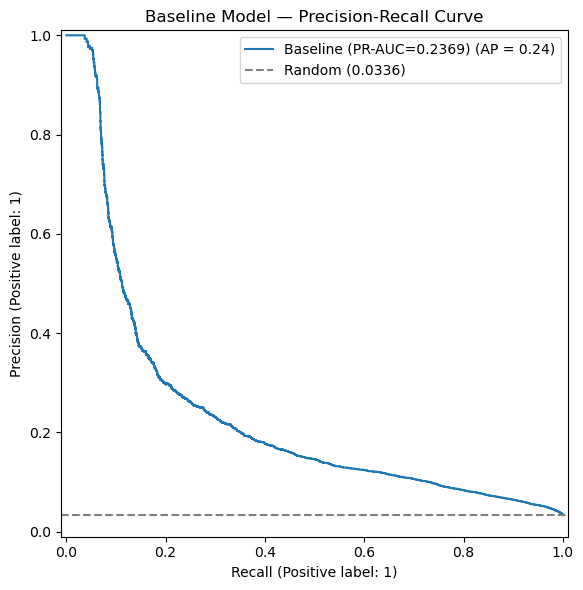

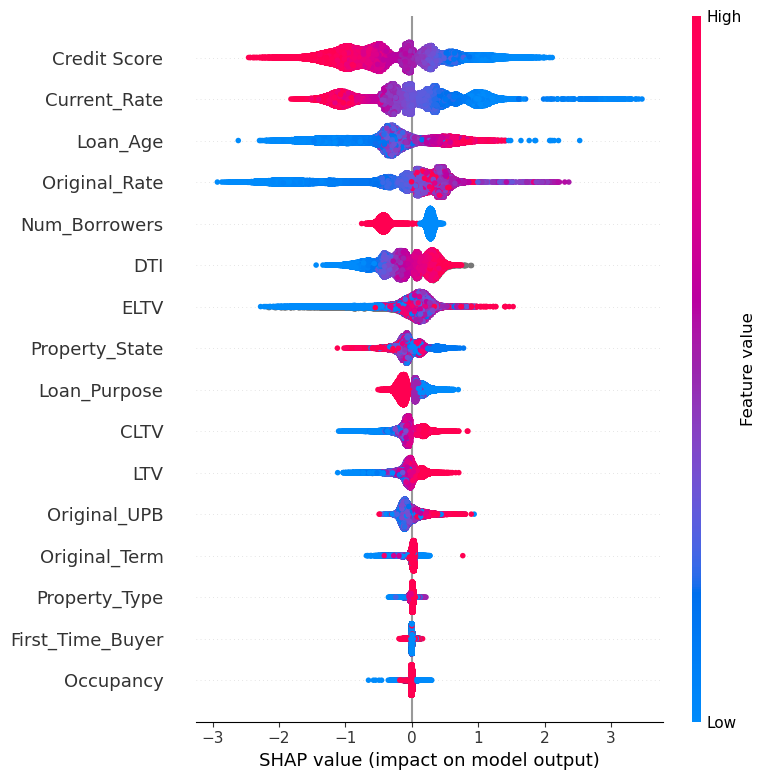

In [83]:
# ── Step 5: Baseline evaluation + SHAP ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_baseline, ax=ax,
    name=f'Baseline (PR-AUC={baseline_pr_auc:.4f})'
)
ax.axhline(y=y_test.mean(), color='grey', linestyle='--',
           label=f'Random ({y_test.mean():.4f})')
ax.set_title('Baseline Model — Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

explainer_baseline = shap.TreeExplainer(baseline_model)
shap_baseline      = explainer_baseline.shap_values(X_baseline_test)
shap.summary_plot(shap_baseline, X_baseline_test, feature_names=baseline_features)

## 7. Climate Model (Credit + Fire + Weather)

In [84]:
# ── Step 6: Climate model (credit + fire + FEMA) ──────────────────────────────
climate_model = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='auc', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
climate_model.fit(
    X_climate_train, y_train,
    eval_set=[(X_climate_test, y_test)],
    verbose=50
)

y_pred_climate  = climate_model.predict_proba(X_climate_test)[:, 1]
climate_roc_auc = roc_auc_score(y_test, y_pred_climate)
climate_pr_auc  = average_precision_score(y_test, y_pred_climate)

print(f'Climate ROC-AUC:  {climate_roc_auc:.4f}')
print(f'Climate PR-AUC:   {climate_pr_auc:.4f}')
print(f'Lift over random: {climate_pr_auc / y_test.mean():.2f}x')

[0]	validation_0-auc:0.76941
[50]	validation_0-auc:0.81663
[100]	validation_0-auc:0.82288
[150]	validation_0-auc:0.82691
[200]	validation_0-auc:0.82912
[250]	validation_0-auc:0.82951
[300]	validation_0-auc:0.83023
[350]	validation_0-auc:0.83038
[398]	validation_0-auc:0.83044
Climate ROC-AUC:  0.8306
Climate PR-AUC:   0.2397
Lift over random: 7.14x


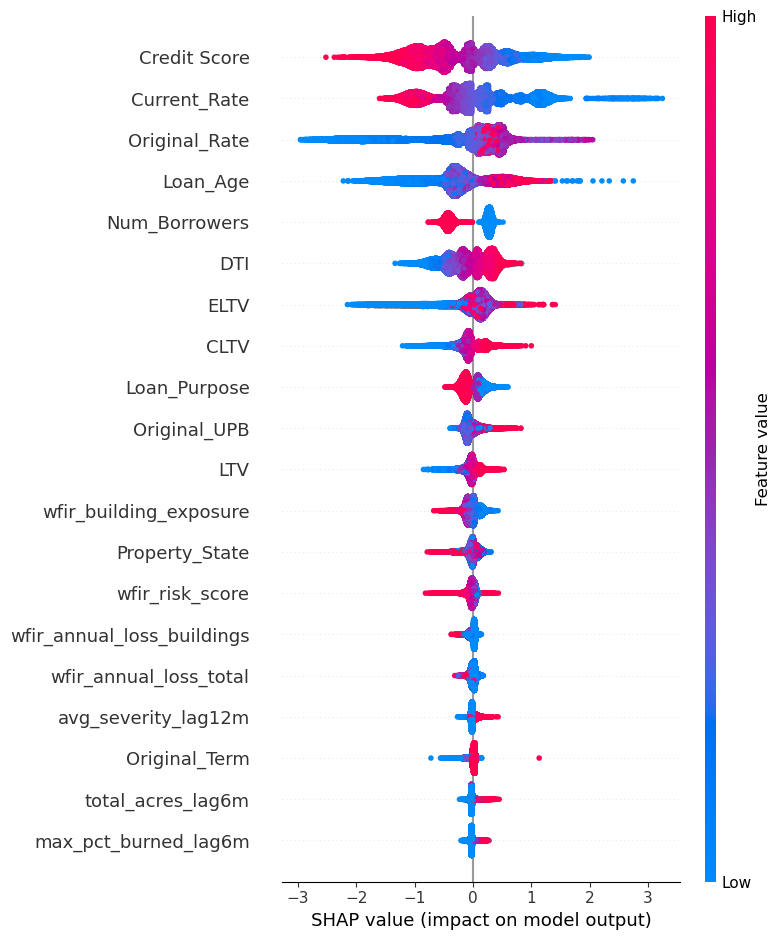

In [85]:
# ── Step 7: Climate evaluation + SHAP ────────────────────────────────────────
explainer_climate = shap.TreeExplainer(climate_model)
shap_climate      = explainer_climate.shap_values(X_climate_test)
shap.summary_plot(shap_climate, X_climate_test, feature_names=climate_features)

## 8. Results Summary

Model                             ROC-AUC     PR-AUC
--------------------------------------------------
Random baseline                    0.0336     0.0336
Baseline (credit only)             0.8301     0.2369
Climate (credit+fire+FEMA)         0.8306     0.2397
--------------------------------------------------
Delta                             +0.0005    +0.0028

Relative PR-AUC lift: +1.2%


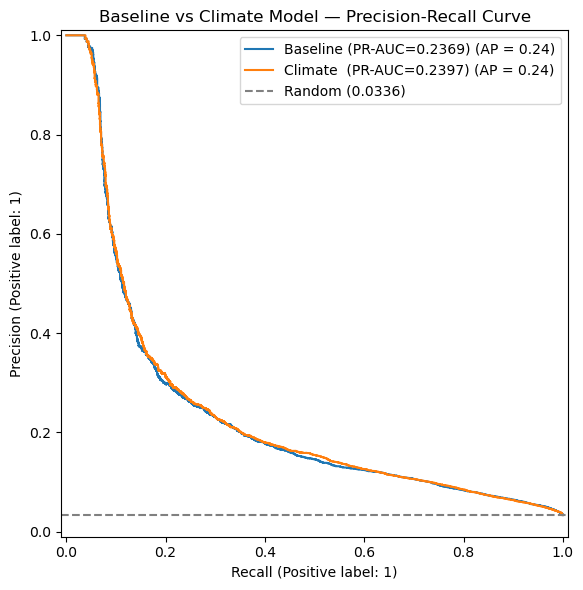

In [86]:
# ── Step 8: Final comparison ──────────────────────────────────────────────────
print('=' * 50)
print(f'{"Model":<30} {"ROC-AUC":>10} {"PR-AUC":>10}')
print('-' * 50)
print(f'{"Random baseline":<30} {y_test.mean():>10.4f} {y_test.mean():>10.4f}')
print(f'{"Baseline (credit only)":<30} {baseline_roc_auc:>10.4f} {baseline_pr_auc:>10.4f}')
print(f'{"Climate (credit+fire+FEMA)":<30} {climate_roc_auc:>10.4f} {climate_pr_auc:>10.4f}')
print('-' * 50)
print(f'{"Delta":<30} {climate_roc_auc-baseline_roc_auc:>+10.4f} {climate_pr_auc-baseline_pr_auc:>+10.4f}')
print(f'\nRelative PR-AUC lift: +{(climate_pr_auc-baseline_pr_auc)/baseline_pr_auc*100:.1f}%')
print('=' * 50)

fig, ax = plt.subplots(figsize=(10, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_baseline, ax=ax,
    name=f'Baseline (PR-AUC={baseline_pr_auc:.4f})'
)
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_climate, ax=ax,
    name=f'Climate  (PR-AUC={climate_pr_auc:.4f})'
)
ax.axhline(y=y_test.mean(), color='grey', linestyle='--',
           label=f'Random ({y_test.mean():.4f})')
ax.set_title('Baseline vs Climate Model — Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [87]:
# States with most fire exposure from MTBS data
fire_state_exposure = (
    zip_hits.merge(
        zctas[['zip', 'geometry']], on='zip', how='left'
    )
)

# Get state from mortgage data — which states have the most fire-affected zip3s
fire_zip3s = zip3_year_month_exposure['zip3'].unique()

state_fire_exposure = (
    mortgage[mortgage['zip3'].isin(fire_zip3s)]
    .groupby('Property State')
    .agg(
        total_loans=('Loan_ID', 'nunique'),
        fire_exposed_loans=('Loan_ID', 'nunique')
    )
    .reset_index()
)

# Simpler — just count unique fire-affected zip3s per state
zip3_to_state = (
    mortgage.groupby('zip3')['Property State']
    .first()
    .reset_index()
)

fire_zip3_states = (
    zip3_to_state[zip3_to_state['zip3'].isin(fire_zip3s)]
    .groupby('Property State')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='fire_zip3_count')
)

print(fire_zip3_states.head(20))

   Property State  fire_zip3_count
0              TX               39
1              CA               38
2              FL               23
3              KY               16
4              CO               16
5              OK               16
6              VA               15
7              KS               15
8              NC               13
9              AL               13
10             GA               13
11             NM               12
12             WA               11
13             AZ               11
14             AR               11
15             WY               11
16             MS               10
17             PA               10
18             MT               10
19             NE                9


In [88]:
# Total zip3s per state in mortgage data
total_zip3_per_state = (
    zip3_to_state
    .groupby('Property State')
    .size()
    .reset_index(name='total_zip3_count')
)

# Join and calculate exposure rate
fire_zip3_states = fire_zip3_states.merge(total_zip3_per_state, on='Property State')
fire_zip3_states['pct_zip3_exposed'] = (
    fire_zip3_states['fire_zip3_count'] / 
    fire_zip3_states['total_zip3_count'] * 100
).round(1)

fire_zip3_states = fire_zip3_states.sort_values('pct_zip3_exposed', ascending=False)
print(fire_zip3_states.head(20))

   Property State  fire_zip3_count  total_zip3_count  pct_zip3_exposed
27             NV                7                 7          100.0000
26             ID                7                 7          100.0000
18             MT               10                10          100.0000
15             WY               11                11          100.0000
13             AZ               11                11          100.0000
4              CO               16                17           94.1000
5              OK               16                17           94.1000
11             NM               12                13           92.3000
2              FL               23                25           92.0000
21             SC                9                10           90.0000
16             MS               10                12           83.3000
0              TX               39                47           83.0000
24             OR                8                10           80.0000
7     

In [89]:
# ── Western states setup ──────────────────────────────────────────────────────
western_fire_states = ['CA', 'NV', 'ID', 'MT', 'WY', 'AZ', 'CO', 'NM', 'OR', 'WA', 'UT']

loan_level['state_orig'] = (
    mortgage.groupby('Loan_ID')['Property State']
    .first()
    .reindex(loan_level['Loan_ID'])
    .values
)

loan_level_west = loan_level[loan_level['state_orig'].isin(western_fire_states)].copy()

print(f'Loan count:    {len(loan_level_west):,}')
print(f'Default rate:  {loan_level_west["Default"].mean():.4f}')
print(f'State breakdown:\n{loan_level_west["state_orig"].value_counts()}')

Loan count:    150,567
Default rate:  0.0302
State breakdown:
state_orig
CA    65732
AZ    17444
CO    16635
WA    16089
OR     9716
UT     9156
NV     6543
ID     3979
NM     2475
MT     1918
WY      880
Name: count, dtype: int64


In [90]:
# ── Western train/test split ──────────────────────────────────────────────────
y_west = loan_level_west['Default']

X_train_west_idx, X_test_west_idx = train_test_split(
    loan_level_west.index, test_size=0.2, random_state=42, stratify=y_west
)

X_baseline_train_w = loan_level_west.loc[X_train_west_idx, baseline_features]
X_baseline_test_w  = loan_level_west.loc[X_test_west_idx,  baseline_features]
X_climate_train_w  = loan_level_west.loc[X_train_west_idx, climate_features]
X_climate_test_w   = loan_level_west.loc[X_test_west_idx,  climate_features]
y_train_w          = y_west.loc[X_train_west_idx]
y_test_w           = y_west.loc[X_test_west_idx]

print(f'Train size: {X_baseline_train_w.shape} | Default rate: {y_train_w.mean():.4f}')
print(f'Test size:  {X_baseline_test_w.shape}  | Default rate: {y_test_w.mean():.4f}')

Train size: (120453, 16) | Default rate: 0.0302
Test size:  (30114, 16)  | Default rate: 0.0302


In [91]:
# ── Western baseline model ────────────────────────────────────────────────────
baseline_model_w = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train_w == 0).sum() / (y_train_w == 1).sum(),
    eval_metric='auc', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
baseline_model_w.fit(
    X_baseline_train_w, y_train_w,
    eval_set=[(X_baseline_test_w, y_test_w)],
    verbose=50
)

y_pred_baseline_w  = baseline_model_w.predict_proba(X_baseline_test_w)[:, 1]
baseline_roc_auc_w = roc_auc_score(y_test_w, y_pred_baseline_w)
baseline_pr_auc_w  = average_precision_score(y_test_w, y_pred_baseline_w)

print(f'Western Baseline ROC-AUC: {baseline_roc_auc_w:.4f}')
print(f'Western Baseline PR-AUC:  {baseline_pr_auc_w:.4f}')
print(f'Lift over random:         {baseline_pr_auc_w / y_test_w.mean():.2f}x')

[0]	validation_0-auc:0.71140
[50]	validation_0-auc:0.81320
[100]	validation_0-auc:0.81856
[150]	validation_0-auc:0.81990
[187]	validation_0-auc:0.81975
Western Baseline ROC-AUC: 0.8202
Western Baseline PR-AUC:  0.1858
Lift over random:         6.15x


In [92]:
# ── Western climate model ─────────────────────────────────────────────────────
climate_model_w = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train_w == 0).sum() / (y_train_w == 1).sum(),
    eval_metric='auc', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
climate_model_w.fit(
    X_climate_train_w, y_train_w,
    eval_set=[(X_climate_test_w, y_test_w)],
    verbose=50
)

y_pred_climate_w  = climate_model_w.predict_proba(X_climate_test_w)[:, 1]
climate_roc_auc_w = roc_auc_score(y_test_w, y_pred_climate_w)
climate_pr_auc_w  = average_precision_score(y_test_w, y_pred_climate_w)

print(f'Western Climate ROC-AUC:  {climate_roc_auc_w:.4f}')
print(f'Western Climate PR-AUC:   {climate_pr_auc_w:.4f}')
print(f'Lift over random:         {climate_pr_auc_w / y_test_w.mean():.2f}x')

[0]	validation_0-auc:0.75976
[50]	validation_0-auc:0.81369
[100]	validation_0-auc:0.81954
[150]	validation_0-auc:0.82269
[200]	validation_0-auc:0.82400
[221]	validation_0-auc:0.82358
Western Climate ROC-AUC:  0.8243
Western Climate PR-AUC:   0.2033
Lift over random:         6.73x


WESTERN STATES SUBGROUP ANALYSIS
Model                             ROC-AUC     PR-AUC
-------------------------------------------------------
Random baseline                    0.0302     0.0302
Baseline (credit only)             0.8202     0.1858
Climate (credit+fire+FEMA)         0.8243     0.2033
-------------------------------------------------------
Delta                             +0.0042    +0.0174

Relative PR-AUC lift: +9.4%


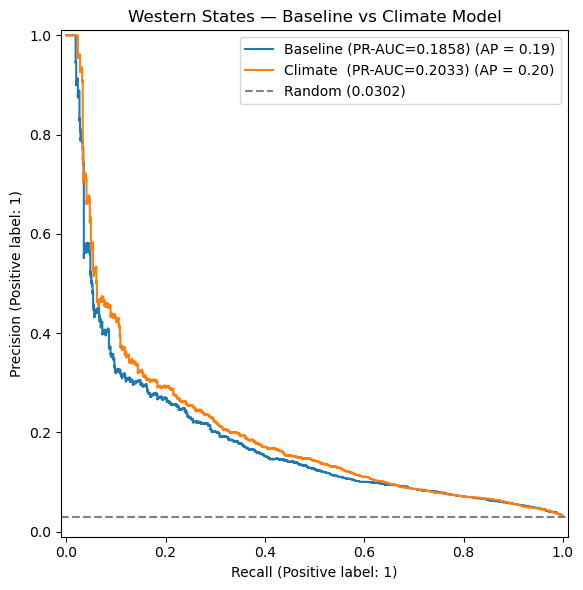

In [93]:
# ── Western results comparison ────────────────────────────────────────────────
print('=' * 55)
print('WESTERN STATES SUBGROUP ANALYSIS')
print('=' * 55)
print(f'{"Model":<30} {"ROC-AUC":>10} {"PR-AUC":>10}')
print('-' * 55)
print(f'{"Random baseline":<30} {y_test_w.mean():>10.4f} {y_test_w.mean():>10.4f}')
print(f'{"Baseline (credit only)":<30} {baseline_roc_auc_w:>10.4f} {baseline_pr_auc_w:>10.4f}')
print(f'{"Climate (credit+fire+FEMA)":<30} {climate_roc_auc_w:>10.4f} {climate_pr_auc_w:>10.4f}')
print('-' * 55)
print(f'{"Delta":<30} {climate_roc_auc_w-baseline_roc_auc_w:>+10.4f} {climate_pr_auc_w-baseline_pr_auc_w:>+10.4f}')
print(f'\nRelative PR-AUC lift: +{(climate_pr_auc_w-baseline_pr_auc_w)/baseline_pr_auc_w*100:.1f}%')
print('=' * 55)

# PR curve
fig, ax = plt.subplots(figsize=(10, 6))
PrecisionRecallDisplay.from_predictions(
    y_test_w, y_pred_baseline_w, ax=ax,
    name=f'Baseline (PR-AUC={baseline_pr_auc_w:.4f})'
)
PrecisionRecallDisplay.from_predictions(
    y_test_w, y_pred_climate_w, ax=ax,
    name=f'Climate  (PR-AUC={climate_pr_auc_w:.4f})'
)
ax.axhline(y=y_test_w.mean(), color='grey', linestyle='--',
           label=f'Random ({y_test_w.mean():.4f})')
ax.set_title('Western States — Baseline vs Climate Model')
ax.legend()
plt.tight_layout()
plt.show()

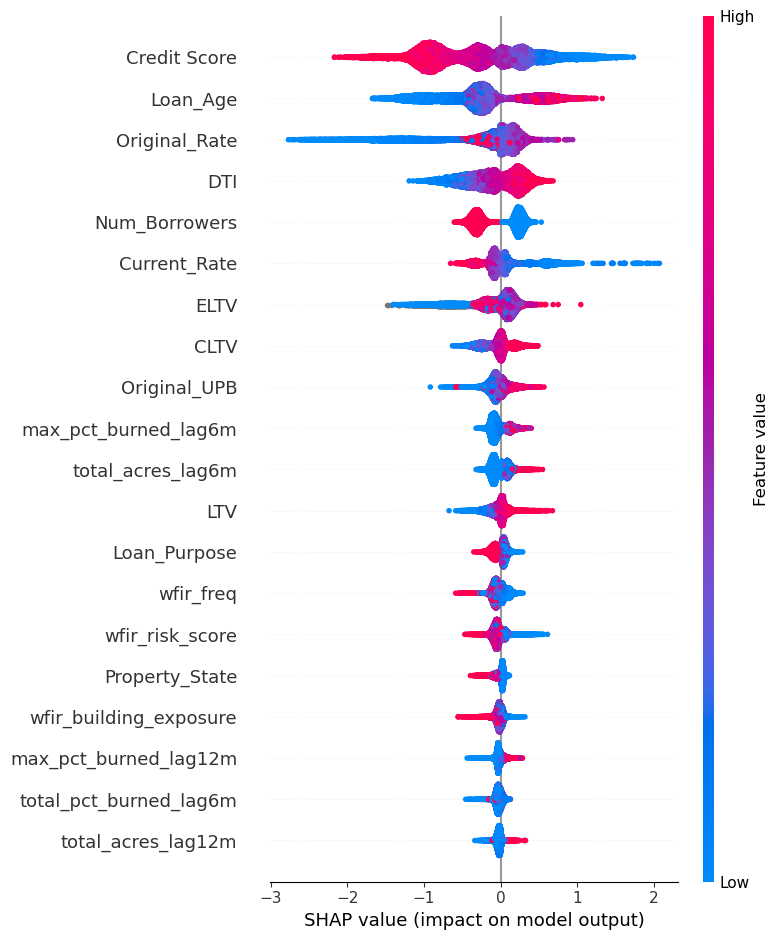

In [94]:
explainer_w = shap.TreeExplainer(climate_model_w)
shap_w = explainer_w.shap_values(X_climate_test_w)
shap.summary_plot(shap_w, X_climate_test_w, feature_names=climate_features)

In [95]:
# Check if high FEMA risk zip3s have higher credit scores
print(
    loan_level_west.groupby(
        pd.qcut(loan_level_west['wfir_risk_score'], q=5)
    )['Credit Score'].mean()
)

wfir_risk_score
(3.745, 34.842]    752.2172
(34.842, 53.441]   751.5766
(53.441, 62.8]     751.2137
(62.8, 73.692]     751.4572
(73.692, 99.397]   750.2962
Name: Credit Score, dtype: float64


/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/3990700358.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_level_west.groupby(


In [96]:
# Check default rate by FEMA risk quintile
print(
    loan_level_west.groupby(
        pd.qcut(loan_level_west['wfir_risk_score'], q=5)
    )['Default'].mean().round(4)
)

# And fire exposure by FEMA risk quintile
print(
    loan_level_west.groupby(
        pd.qcut(loan_level_west['wfir_risk_score'], q=5)
    )['max_pct_burned_lag6m'].mean().round(4)
)

wfir_risk_score
(3.745, 34.842]    0.0326
(34.842, 53.441]   0.0317
(53.441, 62.8]     0.0294
(62.8, 73.692]     0.0283
(73.692, 99.397]   0.0289
Name: Default, dtype: float64
wfir_risk_score
(3.745, 34.842]    0.0431
(34.842, 53.441]   0.1838
(53.441, 62.8]     0.1597
(62.8, 73.692]     0.2016
(73.692, 99.397]   0.2062
Name: max_pct_burned_lag6m, dtype: float64


/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/2735071167.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_level_west.groupby(
/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/2735071167.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_level_west.groupby(


In [97]:
# Loans with BOTH high FEMA risk AND actual fire exposure
high_risk_burned = loan_level_west[
    (loan_level_west['wfir_risk_score'] > 62.8) &  # top 40% FEMA risk
    (loan_level_west['max_pct_burned_lag6m'] > 0)   # actually burned
]['Default'].mean()

high_risk_unburned = loan_level_west[
    (loan_level_west['wfir_risk_score'] > 62.8) &
    (loan_level_west['max_pct_burned_lag6m'] == 0)
]['Default'].mean()

low_risk_burned = loan_level_west[
    (loan_level_west['wfir_risk_score'] <= 34.842) &
    (loan_level_west['max_pct_burned_lag6m'] > 0)
]['Default'].mean()

low_risk_unburned = loan_level_west[
    (loan_level_west['wfir_risk_score'] <= 34.842) &
    (loan_level_west['max_pct_burned_lag6m'] == 0)
]['Default'].mean()

print(f'High FEMA risk + burned:    {high_risk_burned:.4f}')
print(f'High FEMA risk + unburned:  {high_risk_unburned:.4f}')
print(f'Low FEMA risk + burned:     {low_risk_burned:.4f}')
print(f'Low FEMA risk + unburned:   {low_risk_unburned:.4f}')

High FEMA risk + burned:    0.0335
High FEMA risk + unburned:  0.0112
Low FEMA risk + burned:     0.0476
Low FEMA risk + unburned:   0.0290


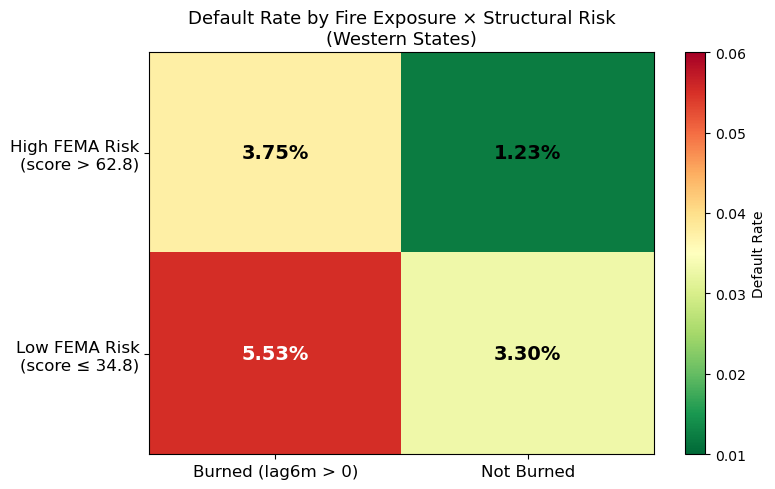

In [98]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

data = np.array([[0.0375, 0.0123],
                 [0.0553, 0.0330]])

im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto', vmin=0.01, vmax=0.06)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Burned (lag6m > 0)', 'Not Burned'], fontsize=12)
ax.set_yticklabels(['High FEMA Risk\n(score > 62.8)', 'Low FEMA Risk\n(score ≤ 34.8)'], fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{data[i,j]*100:.2f}%',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if data[i,j] > 0.04 else 'black')

plt.colorbar(im, ax=ax, label='Default Rate')
ax.set_title('Default Rate by Fire Exposure × Structural Risk\n(Western States)', fontsize=13)
plt.tight_layout()
plt.show()

Delinquency Due to Disaster      N      Y
year                                     
2014                        0.0002 0.0000
2015                        0.0008 0.2143
2016                        0.0014 0.2553
2017                        0.0018 0.2384
2018                        0.0023 0.7043
2019                        0.0025 0.4611
2020                        0.0028 0.5156
2021                        0.0031 0.8465
2022                        0.0028 0.7235
2023                        0.0031 0.6093
2024                        0.0045 0.4557
2025                        0.0056 0.5567


<Figure size 1200x500 with 0 Axes>

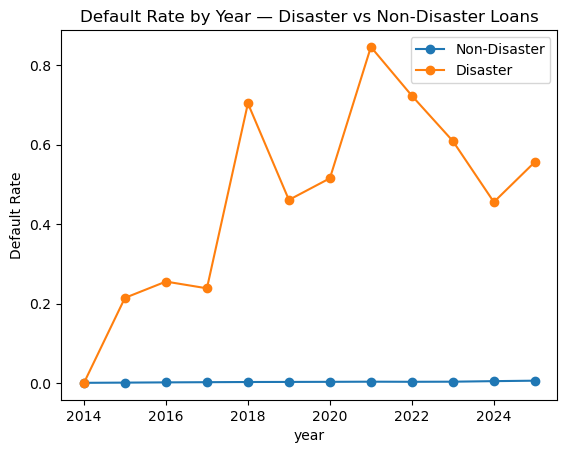

In [99]:
# If COVID is driving everything, disaster defaults should spike in 2020
# If it's genuine climate signal, they should spike in 2017-2019
yearly = mortgage.groupby(['year', 'Delinquency Due to Disaster'])['Default'].mean().unstack()
print(yearly)

plt.figure(figsize=(12, 5))
yearly.plot(marker='o')
plt.title('Default Rate by Year — Disaster vs Non-Disaster Loans')
plt.ylabel('Default Rate')
plt.legend(['Non-Disaster', 'Disaster'])
plt.show()

In [100]:
# ── Check 2: Exclude COVID years (2020-2021) ──────────────────────────────────

# Filter loan level to exclude loans whose first reporting year was 2020-2021
loan_level_no_covid = loan_level[
    ~loan_level['year'].isin([2020, 2021])
].copy()

print(f'Full dataset loans:     {len(loan_level):,}')
print(f'Ex-COVID loans:         {len(loan_level_no_covid):,}')
print(f'Removed:                {len(loan_level) - len(loan_level_no_covid):,}')
print(f'Default rate full:      {loan_level["Default"].mean():.4f}')
print(f'Default rate ex-COVID:  {loan_level_no_covid["Default"].mean():.4f}')

Full dataset loans:     550,000
Ex-COVID loans:         449,386
Removed:                100,614
Default rate full:      0.0336
Default rate ex-COVID:  0.0366


In [101]:
# ── Western states ex-COVID ───────────────────────────────────────────────────
loan_level_no_covid['state_orig'] = (
    mortgage.groupby('Loan_ID')['Property State']
    .first()
    .reindex(loan_level_no_covid['Loan_ID'])
    .values
)

western_fire_states = ['CA', 'NV', 'ID', 'MT', 'WY', 'AZ', 'CO', 'NM', 'OR', 'WA', 'UT']

loan_level_west_nc = loan_level_no_covid[
    loan_level_no_covid['state_orig'].isin(western_fire_states)
].copy()

print(f'Western ex-COVID loans:  {len(loan_level_west_nc):,}')
print(f'Western ex-COVID default rate: {loan_level_west_nc["Default"].mean():.4f}')

Western ex-COVID loans:  119,401
Western ex-COVID default rate: 0.0333


In [102]:
# ── Train/test split ex-COVID western ─────────────────────────────────────────
y_nc = loan_level_west_nc['Default']

X_train_nc_idx, X_test_nc_idx = train_test_split(
    loan_level_west_nc.index, test_size=0.2, random_state=42, stratify=y_nc
)

X_baseline_train_nc = loan_level_west_nc.loc[X_train_nc_idx, baseline_features]
X_baseline_test_nc  = loan_level_west_nc.loc[X_test_nc_idx,  baseline_features]
X_climate_train_nc  = loan_level_west_nc.loc[X_train_nc_idx, climate_features]
X_climate_test_nc   = loan_level_west_nc.loc[X_test_nc_idx,  climate_features]
y_train_nc          = y_nc.loc[X_train_nc_idx]
y_test_nc           = y_nc.loc[X_test_nc_idx]

print(f'Train size: {X_baseline_train_nc.shape} | Default rate: {y_train_nc.mean():.4f}')
print(f'Test size:  {X_baseline_test_nc.shape}  | Default rate: {y_test_nc.mean():.4f}')

Train size: (95520, 16) | Default rate: 0.0333
Test size:  (23881, 16)  | Default rate: 0.0333


In [103]:
# ── Baseline model ex-COVID ───────────────────────────────────────────────────
baseline_model_nc = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train_nc == 0).sum() / (y_train_nc == 1).sum(),
    eval_metric='auc', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
baseline_model_nc.fit(
    X_baseline_train_nc, y_train_nc,
    eval_set=[(X_baseline_test_nc, y_test_nc)],
    verbose=50
)

y_pred_baseline_nc  = baseline_model_nc.predict_proba(X_baseline_test_nc)[:, 1]
baseline_roc_auc_nc = roc_auc_score(y_test_nc, y_pred_baseline_nc)
baseline_pr_auc_nc  = average_precision_score(y_test_nc, y_pred_baseline_nc)

print(f'Ex-COVID Baseline ROC-AUC: {baseline_roc_auc_nc:.4f}')
print(f'Ex-COVID Baseline PR-AUC:  {baseline_pr_auc_nc:.4f}')
print(f'Lift over random:          {baseline_pr_auc_nc / y_test_nc.mean():.2f}x')

[0]	validation_0-auc:0.73505
[50]	validation_0-auc:0.82178
[100]	validation_0-auc:0.82470
[150]	validation_0-auc:0.82592
[172]	validation_0-auc:0.82539
Ex-COVID Baseline ROC-AUC: 0.8262
Ex-COVID Baseline PR-AUC:  0.2002
Lift over random:          6.01x


In [104]:
# ── Climate model ex-COVID ────────────────────────────────────────────────────
climate_model_nc = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train_nc == 0).sum() / (y_train_nc == 1).sum(),
    eval_metric='auc', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
climate_model_nc.fit(
    X_climate_train_nc, y_train_nc,
    eval_set=[(X_climate_test_nc, y_test_nc)],
    verbose=50
)

y_pred_climate_nc  = climate_model_nc.predict_proba(X_climate_test_nc)[:, 1]
climate_roc_auc_nc = roc_auc_score(y_test_nc, y_pred_climate_nc)
climate_pr_auc_nc  = average_precision_score(y_test_nc, y_pred_climate_nc)

print(f'Ex-COVID Climate ROC-AUC:  {climate_roc_auc_nc:.4f}')
print(f'Ex-COVID Climate PR-AUC:   {climate_pr_auc_nc:.4f}')
print(f'Lift over random:          {climate_pr_auc_nc / y_test_nc.mean():.2f}x')

[0]	validation_0-auc:0.77096
[50]	validation_0-auc:0.82655
[100]	validation_0-auc:0.82982
[150]	validation_0-auc:0.83199
[200]	validation_0-auc:0.83189
[211]	validation_0-auc:0.83133
Ex-COVID Climate ROC-AUC:  0.8324
Ex-COVID Climate PR-AUC:   0.2241
Lift over random:          6.72x


ROBUSTNESS CHECK — EXCLUDING COVID YEARS (2020-2021)
WESTERN STATES ONLY
Model                                  ROC-AUC     PR-AUC
------------------------------------------------------------
Random baseline                         0.0333     0.0333
Baseline ex-COVID (credit only)         0.8262     0.2002
Climate ex-COVID (credit+fire+FEMA)     0.8324     0.2241
------------------------------------------------------------
Delta                                  +0.0062    +0.0238

Relative PR-AUC lift: +11.9%

COMPARISON: WITH vs WITHOUT COVID YEARS
Scenario                             ROC delta   PR delta
------------------------------------------------------------
Western (with COVID)                   +0.0042    +0.0174
Western (ex-COVID)                     +0.0062    +0.0238


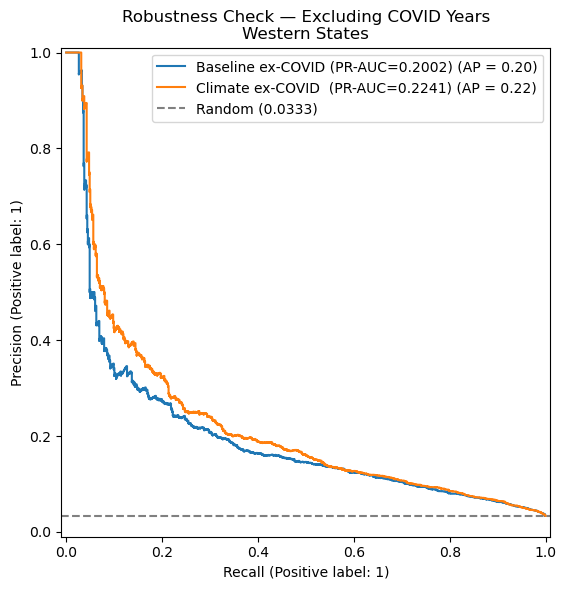

In [105]:
# ── Full comparison table ─────────────────────────────────────────────────────
print('=' * 60)
print('ROBUSTNESS CHECK — EXCLUDING COVID YEARS (2020-2021)')
print('WESTERN STATES ONLY')
print('=' * 60)
print(f'{"Model":<35} {"ROC-AUC":>10} {"PR-AUC":>10}')
print('-' * 60)
print(f'{"Random baseline":<35} {y_test_nc.mean():>10.4f} {y_test_nc.mean():>10.4f}')
print(f'{"Baseline ex-COVID (credit only)":<35} {baseline_roc_auc_nc:>10.4f} {baseline_pr_auc_nc:>10.4f}')
print(f'{"Climate ex-COVID (credit+fire+FEMA)":<35} {climate_roc_auc_nc:>10.4f} {climate_pr_auc_nc:>10.4f}')
print('-' * 60)
print(f'{"Delta":<35} {climate_roc_auc_nc-baseline_roc_auc_nc:>+10.4f} {climate_pr_auc_nc-baseline_pr_auc_nc:>+10.4f}')
print(f'\nRelative PR-AUC lift: +{(climate_pr_auc_nc-baseline_pr_auc_nc)/baseline_pr_auc_nc*100:.1f}%')
print('=' * 60)

# Compare with and without COVID
print('\n' + '=' * 60)
print('COMPARISON: WITH vs WITHOUT COVID YEARS')
print('=' * 60)
print(f'{"Scenario":<35} {"ROC delta":>10} {"PR delta":>10}')
print('-' * 60)
print(f'{"Western (with COVID)":<35} {climate_roc_auc_w-baseline_roc_auc_w:>+10.4f} {climate_pr_auc_w-baseline_pr_auc_w:>+10.4f}')
print(f'{"Western (ex-COVID)":<35} {climate_roc_auc_nc-baseline_roc_auc_nc:>+10.4f} {climate_pr_auc_nc-baseline_pr_auc_nc:>+10.4f}')
print('=' * 60)


# PR curve
fig, ax = plt.subplots(figsize=(10, 6))
PrecisionRecallDisplay.from_predictions(
    y_test_nc, y_pred_baseline_nc, ax=ax,
    name=f'Baseline ex-COVID (PR-AUC={baseline_pr_auc_nc:.4f})'
)
PrecisionRecallDisplay.from_predictions(
    y_test_nc, y_pred_climate_nc, ax=ax,
    name=f'Climate ex-COVID  (PR-AUC={climate_pr_auc_nc:.4f})'
)
ax.axhline(y=y_test_nc.mean(), color='grey', linestyle='--',
           label=f'Random ({y_test_nc.mean():.4f})')
ax.set_title('Robustness Check — Excluding COVID Years\nWestern States')
ax.legend()
plt.tight_layout()
plt.show()

In [106]:
# Get disaster-flagged loans with location and timing
disaster_details = (
    mortgage[mortgage['Delinquency Due to Disaster'] == 'Y']
    .groupby('Loan_ID')
    .agg(
        state=('Property State', 'first'),
        zip3=('zip3', 'first'),
        first_disaster_period=('period', 'min'),  # when flag first appeared
    )
    .reset_index()
)

disaster_details['first_disaster_year']  = disaster_details['first_disaster_period'] // 100
disaster_details['first_disaster_month'] = disaster_details['first_disaster_period'] % 100

print(disaster_details.groupby(['state', 'first_disaster_year']).size()
      .sort_values(ascending=False).head(20))

state  first_disaster_year
CA     2020                   2309
TX     2020                   1454
FL     2020                   1351
NY     2020                    936
IL     2020                    695
NJ     2020                    630
GA     2020                    521
MI     2020                    475
FL     2017                    443
PA     2020                    400
AZ     2020                    375
CO     2020                    374
NC     2020                    368
OH     2020                    362
WA     2020                    345
MD     2020                    317
VA     2020                    301
MA     2020                    276
UT     2020                    274
MN     2020                    269
dtype: int64


In [107]:
# What fires occurred in those state-years?
# Get the biggest fires per state per year from MTBS
big_fires = (
    mtbs_filtered[mtbs_filtered['Incid_Type'] == 'Wildfire']
    .groupby(['fire_year'])
    .apply(lambda x: x.nlargest(3, 'BurnBndAc')[['Incid_Name', 'fire_year', 'BurnBndAc', 'BurnBndLat', 'BurnBndLon']])
    .reset_index(drop=True)
)

print(big_fires.sort_values('fire_year'))

               Incid_Name  fire_year  BurnBndAc BurnBndLat BurnBndLon
0                  WALLOW       2011     563664     33.799   -109.253
1              ROCK HOUSE       2011     299170     30.623   -103.936
2             HORSESHOE 2       2011     226079     31.907   -109.275
3               LONG DRAW       2012     500045     42.428   -117.625
4                HOLLOWAY       2012     457931     41.998   -118.248
5         MUSTANG COMPLEX       2012     377632     45.473   -114.506
6                     RIM       2013     257084     37.916   -119.969
7              LIME HILLS       2013     193968     61.546   -155.429
8            PONY COMPLEX       2013     148188     43.385   -115.651
11            FUNNY RIVER       2014     193798     60.313   -150.829
9             SADDLE DRAW       2014     284065     43.284   -118.063
10        CARLTON COMPLEX       2014     276249     48.248    -119.96
12     MIDDLE YUKON FIRES       2015     407461      64.55   -154.764
13                  

/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/3128954768.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'BurnBndAc')[['Incid_Name', 'fire_year', 'BurnBndAc', 'BurnBndLat', 'BurnBndLon']])


In [108]:
# For each year, which zip3s had BOTH disaster flags AND recorded fires?
disaster_zip3_year = (
    disaster_details.groupby(['first_disaster_year', 'zip3'])
    .size()
    .reset_index(name='disaster_loan_count')
)

fire_zip3_year = (
    zip3_year_month_exposure.groupby(['fire_year', 'zip3'])
    .agg(total_acres=('total_acres', 'sum'))
    .reset_index()
)

# Join — where do disaster loans and fires overlap?
overlap = disaster_zip3_year.merge(
    fire_zip3_year,
    left_on=['first_disaster_year', 'zip3'],
    right_on=['fire_year', 'zip3'],
    how='inner'
).sort_values('disaster_loan_count', ascending=False)

print(f'Disaster loan zip3-years with confirmed fires: {len(overlap)}')
print(overlap.head(20))

Disaster loan zip3-years with confirmed fires: 627
     first_disaster_year zip3  disaster_loan_count  fire_year  total_acres
271                 2020  945                  175       2020      4660268
130                 2020  330                  172       2020        32943
229                 2020  840                  172       2020       266012
250                 2020  891                  170       2020         8279
131                 2020  331                  169       2020         4942
261                 2020  925                  138       2020        32669
132                 2020  334                  132       2020         1315
197                 2020  774                  132       2020         1992
255                 2020  913                  118       2020         5667
260                 2020  923                  100       2020       314325
235                 2020  852                   95       2020       240546
256                 2020  917                   9

In [113]:
for _, row in pre_covid_overlap.head(15).iterrows():
    fires_in_zip_year = zip_hits[
        (zip_hits['fire_year'] == row['fire_year']) &
        (zip_hits['zip'].astype(str).str.zfill(5).str[:3] == row['zip3'])
    ].merge(
        mtbs_filtered[['Event_ID', 'Incid_Name']],
        on='Event_ID',
        how='left'
    )[['Incid_Name', 'fire_year', 'BurnBndAc', 'pct_burned']].sort_values(
        'BurnBndAc', ascending=False
    ).drop_duplicates()

    print(f"\nzip3={row['zip3']}, year={row['fire_year']}, "
          f"disaster_loans={row['disaster_loan_count']:.0f}, "
          f"total_acres={row['total_acres']:,.0f}")
    print(fires_in_zip_year.head(3).to_string())
    print()


zip3=331, year=2017, disaster_loans=80, total_acres=1,508
   Incid_Name  fire_year  BurnBndAc  pct_burned
0  TRAIL FIRE       2017       1508      0.0338


zip3=330, year=2017, disaster_loans=62, total_acres=15,514
    Incid_Name  fire_year  BurnBndAc  pct_burned
1      HOLIDAY       2017       8858      0.0009
0  MOTHERS DAY       2017       3328      0.1723
2  MOTHERS DAY       2017       3328      0.0012


zip3=774, year=2017, disaster_loans=43, total_acres=5,745
                 Incid_Name  fire_year  BurnBndAc  pct_burned
1     2018 NORTH SARGENT WF       2017       3959      0.0108
0  TX TMR FY18 RX RAIL POND       2017       1786      0.0153


zip3=334, year=2017, disaster_loans=42, total_acres=59,184
     Incid_Name  fire_year  BurnBndAc  pct_burned
1    THREE MILE       2017      26683      0.0000
4       COWBELL       2017      21781      0.0002
3  CRANE ISLAND       2017       5103      0.0227


zip3=775, year=2017, disaster_loans=31, total_acres=12,556
                Inci

In [114]:
overlap_2018 = overlap[overlap['fire_year'] == 2018].sort_values(
    'disaster_loan_count', ascending=False
)
print(f'2018 overlaps: {len(overlap_2018)}')
print(overlap_2018.head(10).to_string())

# Name the 2018 fires
for _, row in overlap_2018.head(5).iterrows():
    fires = zip_hits[
        (zip_hits['fire_year'] == 2018) &
        (zip_hits['zip'].astype(str).str.zfill(5).str[:3] == row['zip3'])
    ].merge(
        mtbs_filtered[['Event_ID', 'Incid_Name']],
        on='Event_ID', how='left'
    )[['Incid_Name', 'BurnBndAc', 'pct_burned']].sort_values(
        'BurnBndAc', ascending=False
    ).drop_duplicates()
    
    print(f"\nzip3={row['zip3']}, disaster_loans={row['disaster_loan_count']:.0f}")
    print(fires.head(3).to_string())

2018 overlaps: 30
    first_disaster_year zip3  disaster_loan_count  fire_year  total_acres
59                 2018  284                   16       2018         1118
86                 2018  959                    8       2018      2360332
68                 2018  331                    6       2018        32564
64                 2018  324                    5       2018        10917
83                 2018  930                    5       2018       200351
70                 2018  338                    5       2018         7017
66                 2018  329                    4       2018         3249
67                 2018  330                    4       2018        35814
60                 2018  285                    3       2018          765
58                 2018  283                    3       2018         3060

zip3=284, disaster_loans=16
      Incid_Name  BurnBndAc  pct_burned
0  OLD HOUSE BAY        559      0.0086
1  OLD HOUSE BAY        559      0.0004

zip3=959, disaster

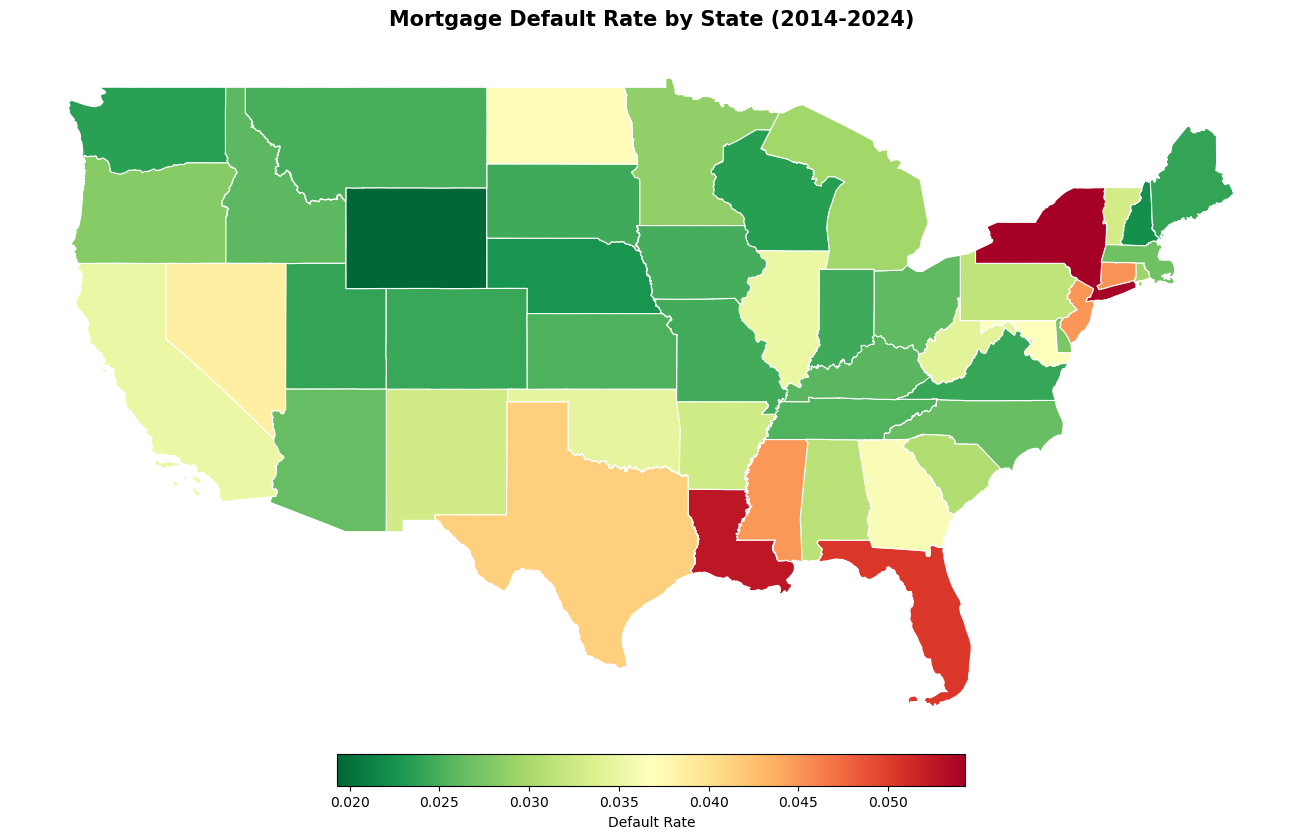

In [115]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Get default rate by state
state_default = (
    loan_level.groupby('state_orig')['Default']
    .mean()
    .reset_index()
    .rename(columns={'state_orig': 'state', 'Default': 'default_rate'})
)

# Load US states
states_gdf = gpd.read_file(
    'https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip'
)

# Merge
states_gdf = states_gdf.merge(
    state_default, left_on='STUSPS', right_on='state', how='left'
)

# CONUS only
conus = states_gdf[~states_gdf['STUSPS'].isin([
    'AK', 'HI', 'PR', 'VI', 'GU', 'MP', 'AS'
])]

fig, ax = plt.subplots(figsize=(16, 9))

conus.plot(
    column='default_rate',
    ax=ax,
    legend=True,
    cmap='RdYlGn_r',
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={
        'label': 'Default Rate',
        'orientation': 'horizontal',
        'shrink': 0.4,
        'pad': 0.02
    },
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Mortgage Default Rate by State (2014-2024)',
             fontsize=15, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

/var/folders/6v/6mrfc7pd27z2lv9tls0_cd9c0000gp/T/ipykernel_6560/3180374594.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['max_pct_burned_lag6m'] > 0).mean())


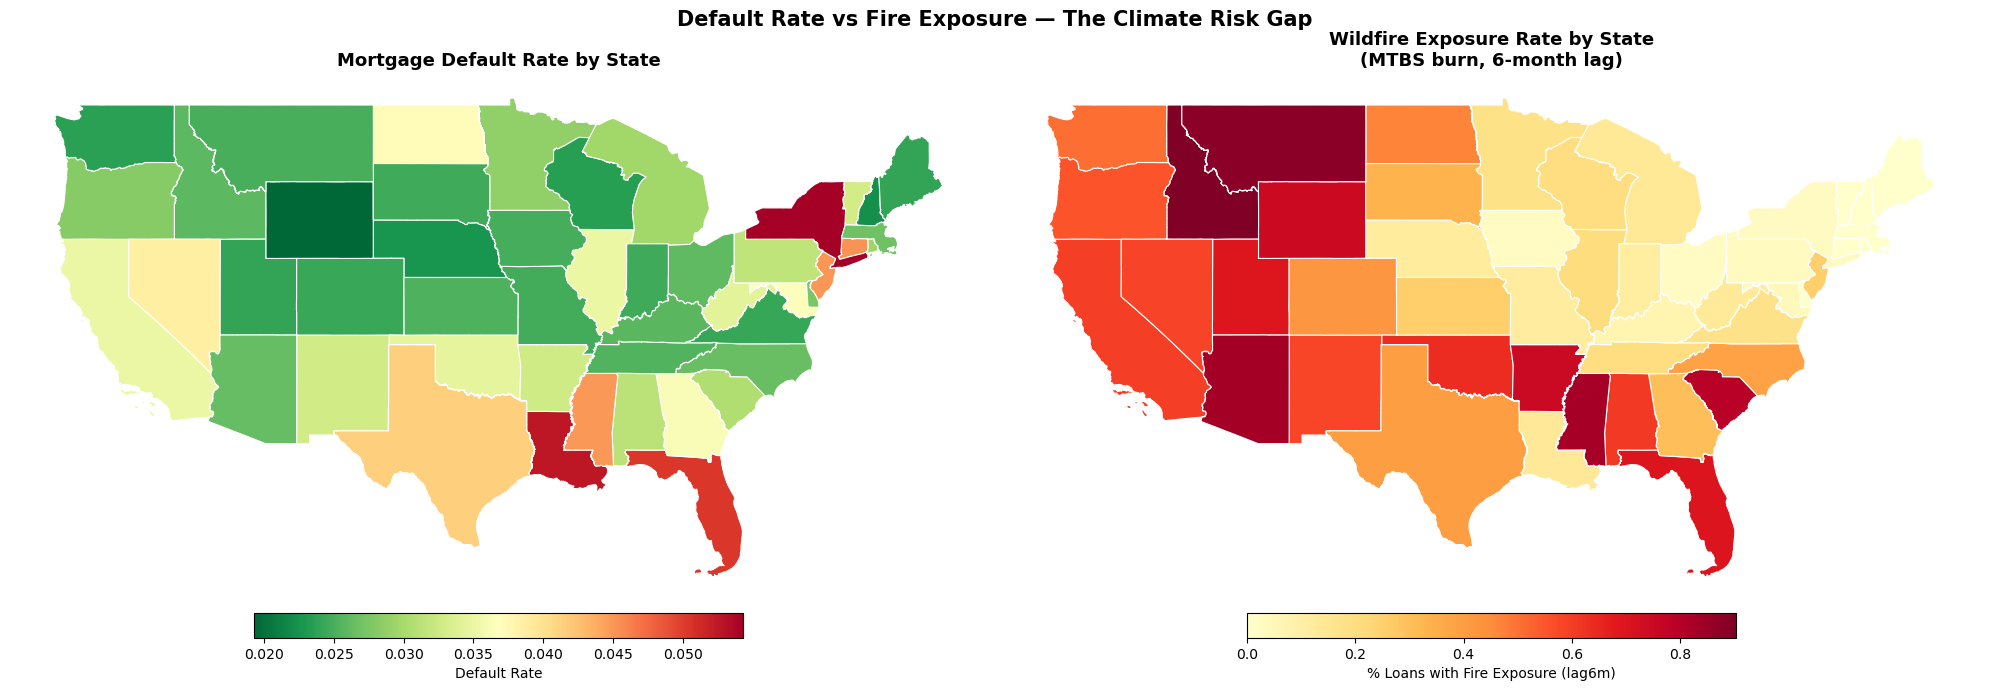

In [116]:
# Fire exposure rate by state
fire_exposure_by_state = (
    loan_level.groupby('state_orig')
    .apply(lambda x: (x['max_pct_burned_lag6m'] > 0).mean())
    .reset_index()
    .rename(columns={'state_orig': 'state', 0: 'pct_fire_exposed'})
)

states_gdf2 = gpd.read_file(
    'https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip'
)
states_gdf2 = states_gdf2.merge(
    fire_exposure_by_state, left_on='STUSPS', right_on='state', how='left'
)
conus2 = states_gdf2[~states_gdf2['STUSPS'].isin([
    'AK', 'HI', 'PR', 'VI', 'GU', 'MP', 'AS'
])]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

conus.plot(
    column='default_rate', ax=axes[0],
    legend=True, cmap='RdYlGn_r',
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Default Rate',
                 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.02},
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Mortgage Default Rate by State', fontsize=13, fontweight='bold')
axes[0].axis('off')

conus2.plot(
    column='pct_fire_exposed', ax=axes[1],
    legend=True, cmap='YlOrRd',
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': '% Loans with Fire Exposure (lag6m)',
                 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.02},
    edgecolor='white', linewidth=0.8
)
axes[1].set_title('Wildfire Exposure Rate by State\n(MTBS burn, 6-month lag)',
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Default Rate vs Fire Exposure — The Climate Risk Gap',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [117]:
# Southeast states
southeast_states = ['FL', 'LA', 'MS', 'AL', 'GA', 'SC', 'NC', 'AR']

# Default rate and fire exposure for southeast vs west
for region, states in [('Southeast', southeast_states), 
                        ('West', western_fire_states)]:
    region_loans = loan_level[loan_level['state_orig'].isin(states)]
    print(f'\n{region}:')
    print(f'  Default rate:         {region_loans["Default"].mean():.4f}')
    print(f'  % fire exposed:       {(region_loans["max_pct_burned_lag6m"] > 0).mean():.4f}')
    print(f'  Avg FEMA risk score:  {region_loans["wfir_risk_score"].mean():.2f}')
    print(f'  Loan count:           {len(region_loans):,}')


Southeast:
  Default rate:         0.0400
  % fire exposed:       0.5520
  Avg FEMA risk score:  61.39
  Loan count:           99,018

West:
  Default rate:         0.0302
  % fire exposed:       0.6115
  Avg FEMA risk score:  55.29
  Loan count:           150,567


In [118]:
# Within southeast, do fire-exposed loans default more?
se_loans = loan_level[loan_level['state_orig'].isin(southeast_states)].copy()
se_loans['fire_exposed'] = (se_loans['max_pct_burned_lag6m'] > 0).astype(int)

print('\nSoutheast default rate by fire exposure:')
print(se_loans.groupby('fire_exposed')['Default'].mean().round(4))

# Same for west
w_loans = loan_level[loan_level['state_orig'].isin(western_fire_states)].copy()
w_loans['fire_exposed'] = (w_loans['max_pct_burned_lag6m'] > 0).astype(int)

print('\nWestern default rate by fire exposure:')
print(w_loans.groupby('fire_exposed')['Default'].mean().round(4))


Southeast default rate by fire exposure:
fire_exposed
0   0.0297
1   0.0485
Name: Default, dtype: float64

Western default rate by fire exposure:
fire_exposed
0   0.0201
1   0.0367
Name: Default, dtype: float64
